# Peripheral Strategy Backtest

This notebook tests the following specific signal:
- **Long** the peripheral stocks when the central portfolio's lagged return is positive.
- **Short** the peripheral stocks when the central portfolio's lagged return is negative.

The central and peripheral portfolios are created by stacking all out-of-sample years into one continuous series for each estimation window $k$ ($k=1$ and $k=10$). We then report the Annualized Return and Sharpe Ratio of this signal.

                       Ann Ret (%)  Ann Vol (%)    Sharpe
Strategy                                                 
Lead-Lag Graph (k=1)     -3.667421    14.609778 -0.251025
Lead-Lag Graph (k=10)    -6.946688    16.370343 -0.424346
Lead-Lag Graph (k=30)    -7.990233    16.368232 -0.488155
1/N Market Benchmark      9.654189    18.966176  0.509021


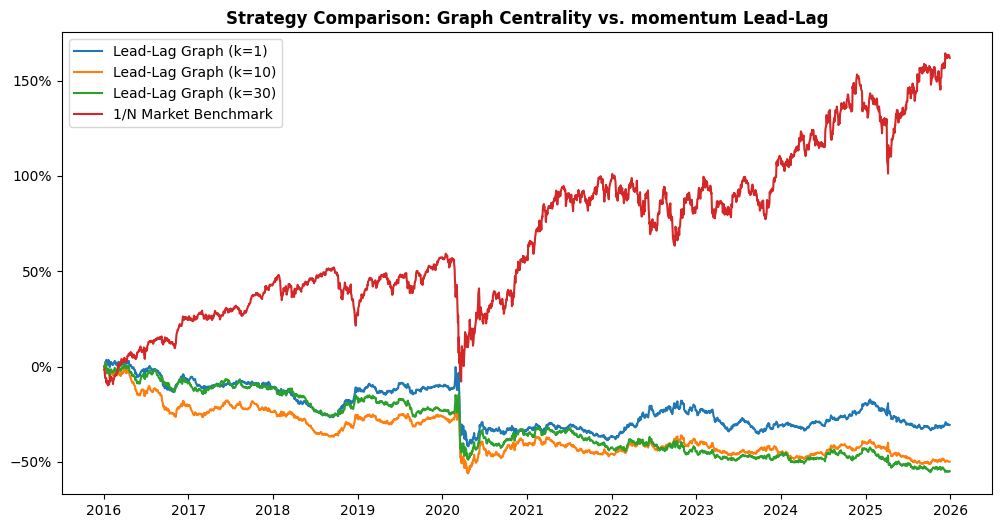

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

years = range(2015, 2025)
centralities = ["central", "peripheral"]
k_values = [1, 10, 30]

# 1. Load the full returns dataset ONCE outside the loop to save time
df_ret_full = pd.read_parquet("../../data/02_clean/returns_30_years.parquet")
# df_ret_full.index = pd.to_datetime(df_ret_full.index)
# df_ret_full = df_ret_full[~df_ret_full.index.duplicated(keep='first')].sort_index()
df_ret_full = df_ret_full[df_ret_full.index >= pd.Timestamp(2016, 1, 1)]

# Load metadata for market cap
df_mcap = pd.read_csv("../../data/07_portfolios_metadata/all_tickers_complete_metadata.csv")
df_mcap = df_mcap[df_mcap["Ticker"].isin(df_ret_full.columns)]

strategy_returns_dict = {}

strategy_returns_dict = {}

for k in k_values:
    peripheral_strat_list = []
    active_smb_strat_list = []
    market_returns_list = []
    
    for year in years:
        # 1. Load your portfolios
        path_central = f"../../data/06_portfolios/central_{year}_{k}.csv"
        path_peripheral = f"../../data/06_portfolios/peripheral_{year}_{k}.csv"
        
        cols_central = pd.read_csv(path_central, index_col="Date").columns.tolist()
        cols_peripheral = pd.read_csv(path_peripheral, index_col="Date").columns.tolist()
        
        # 2. Subset returns for out-of-sample year
        df_ret = df_ret_full[df_ret_full.index.year == (year + 1)]

        # 3. Calculate Daily Log Returns for each group (VW Excess)
        mcap_col = f"mcap_{year}"
        if mcap_col not in df_mcap.columns:
            mcap_col = [c for c in df_mcap.columns if "mcap_" in c][-1]
            
        def get_vw_returns(port_cols):
            mcaps = df_mcap[df_mcap["Ticker"].isin(port_cols)][["Ticker", mcap_col]].copy()
            mcaps[mcap_col] = pd.to_numeric(
                mcaps[mcap_col].astype(str).str.replace(',', '.'), 
                errors='coerce'
            ).fillna(0)
            weights_df = pd.DataFrame({"Ticker": port_cols}).merge(mcaps, on="Ticker", how="left").fillna(0)
            w = weights_df[mcap_col].values
            if w.sum() == 0:
                w = np.ones(len(w)) / len(w)
            else:
                w = w / w.sum()
            return (np.log1p(df_ret[port_cols]) * w).sum(axis=1)
            
        R_m = np.log1p(df_ret).mean(axis=1)
        
        ret_central = get_vw_returns(cols_central) - R_m
        ret_peripheral = get_vw_returns(cols_peripheral) - R_m
        
        # --- STRATEGY A: GRAPH LEAD-LAG (Central -> Peripheral) ---
        sig_graph = np.sign(ret_central.shift(1)).fillna(0)
        strat_graph = sig_graph * ret_peripheral
        peripheral_strat_list.append(strat_graph)
        
        # Benchmark: Market
        market_returns_list.append(np.log1p(df_ret).mean(axis=1))

    # Store results for this K
    strategy_returns_dict[f'Lead-Lag Graph (k={k})'] = pd.concat(peripheral_strat_list).dropna()
    
    # We only need to store these once (they don't depend on K)
    if k == k_values[-1]:
        strategy_returns_dict['1/N Market Benchmark'] = pd.concat(market_returns_list).dropna()

# --- PERFORMANCE TABLE ---
stats = []
for name, rets in strategy_returns_dict.items():
    ann_ret = rets.mean() * 252
    ann_vol = rets.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol
    stats.append({"Strategy": name, "Ann Ret (%)": ann_ret*100, "Ann Vol (%)": ann_vol*100, "Sharpe": sharpe})

df_performance = pd.DataFrame(stats).set_index("Strategy")
print(df_performance)

# --- PLOTTING ---
plt.figure(figsize=(12, 6))
for name, rets in strategy_returns_dict.items():
    cum_ret = np.exp(rets.cumsum()) - 1
    plt.plot(cum_ret.index, cum_ret, label=name)

plt.title('Strategy Comparison: Graph Centrality vs. momentum Lead-Lag', fontweight='bold')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend()
plt.show()

In [14]:
sig_graph

Date
2025-01-02    0.0
2025-01-03    0.0
2025-01-06    0.0
2025-01-07    0.0
2025-01-08    0.0
             ... 
2025-12-23    0.0
2025-12-24    0.0
2025-12-26    0.0
2025-12-29    0.0
2025-12-30    0.0
Length: 249, dtype: float64

--- Strategy Performance Comparison ---
                                     Ann. Return (%)  Ann. Volatility (%)  \
Strategy                                                                    
Lead-Lag Graph (k=1)                           -1.57                18.37   
Lead-Lag Graph (k=10)                          12.02                23.89   
Active Size Strategy (Large->Small)            24.74                21.02   
1/N Market Benchmark                          -16.57                23.30   

                                     Sharpe Ratio  Max Drawdown (%)  
Strategy                                                             
Lead-Lag Graph (k=1)                        -0.09            -34.49  
Lead-Lag Graph (k=10)                        0.50            -30.75  
Active Size Strategy (Large->Small)          1.18            -19.99  
1/N Market Benchmark                        -0.71            -57.96  


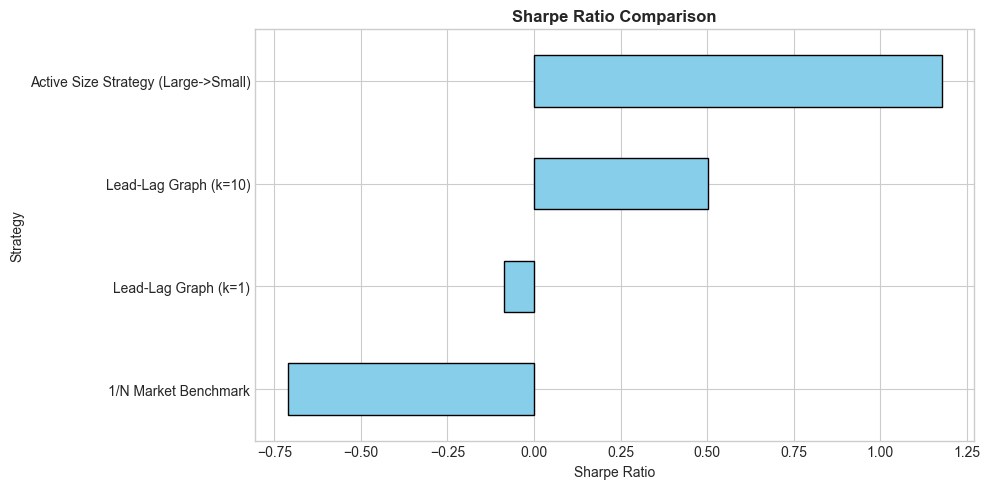

In [13]:
import pandas as pd
import numpy as np

# 1. Setup constants
TRADING_DAYS = 252
RISK_FREE_RATE = 0.0  # Adjust if you have a specific benchmark rate

stats_list = []

for name, rets in strategy_returns_dict.items():
    # We use simple arithmetic returns for standard financial metrics 
    # but since you've stored log returns, we use the following:
    
    # Annualized Return (Geometric mean approach for log returns)
    ann_return = rets.mean() * TRADING_DAYS
    
    # Annualized Volatility
    ann_vol = rets.std() * np.sqrt(TRADING_DAYS)
    
    # Sharpe Ratio
    sharpe = (ann_return - RISK_FREE_RATE) / ann_vol if ann_vol != 0 else np.nan
    
    # Optional: Max Drawdown (adds great context to the 60% gain)
    cum_rets = rets.cumsum() # in log space
    wealth_index = np.exp(cum_rets)
    previous_peaks = wealth_index.cummax()
    drawdowns = (wealth_index - previous_peaks) / previous_peaks
    max_drawdown = drawdowns.min()

    stats_list.append({
        "Strategy": name,
        "Ann. Return (%)": ann_return * 100,
        "Ann. Volatility (%)": ann_vol * 100,
        "Sharpe Ratio": sharpe,
        "Max Drawdown (%)": max_drawdown * 100
    })

# 2. Create and Format DataFrame
df_stats = pd.DataFrame(stats_list).set_index("Strategy")

# Apply styling for better readability
pd.options.display.float_format = '{:,.2f}'.format
print("--- Strategy Performance Comparison ---")
print(df_stats)

# 3. Quick Visualization of Sharpe Ratios
plt.figure(figsize=(10, 5))
df_stats['Sharpe Ratio'].sort_values().plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Sharpe Ratio Comparison', fontweight='bold')
plt.xlabel('Sharpe Ratio')
plt.tight_layout()
plt.show()